# Motivating Examples: Error Handling

In [ ]:
def split_share(total_cost, user_num):
    return total_cost / user_num

split_share(10, 0)

**Error handling** allows us to catch and manage errors (exceptions) that occur during the execution of program, preventing it from crashing. This provides a way to handle errors and allows the program to continue running or respond in a controlled manner.

The syntax is a `try-except` block as follows:

```
try:
    # Code that may raise an exception
except SomeException:
    # Code that runs if the exception occurs
```

`try` block: The code that you want to run, but that might potentially raise an exception.

`except` block: This specifies what to do if an exception occurs during the execution of the try block. You can specify different exceptions or handle all exceptions in a generic manner.

In [ ]:
def split_share(total_cost, user_num):
    try:
        return total_cost / user_num
    except ZeroDivisionError as error: # exception here
        print(f"{error}: No participant of this event.")

split_share(10, 0)

In [ ]:
# handle generic exception

def split_share(total_cost, user_num):
    try:
        return total_cost / user_num
    except Exception as error:
        print(f"{error}: No participant of this event.")

split_share(10, 0)

We can use multiple `except` blocks to address multiple exceptions.

In [ ]:
def split_share(total_cost, user_num):
    try:
        return total_cost / user_num
    except ZeroDivisionError as error: # want to catch an exception
        print(f"{error}: No participant of this event.")
    except TypeError as error: #input is not some number I can import division
        print(f"{error}: number of participants must be a number")

split_share(10, '3')

We can add an `else` statement following the `except` block.
The instructions in the `else` block will be executed only if no exceptions occur.

In [ ]:
def split_share(total_cost, user_num): # same like if-else statement but the logic is different 
    try:
        share = total_cost / user_num
    except ZeroDivisionError as error:
        print(f"{error}: No participant of this event.")
    except TypeError as error:
        print(f"{error}: number of participants must be a number")
    else:
        print(f"Each participant's share is {share}")


split_share(10, 2)

We can add an `finally` statement following the `except` block.
The instructions in the `finally` block will be executed regardless whether exceptions occur or not.

In [1]:
def split_share(total_cost, user_num):
    try:
        share = total_cost / user_num
    except ZeroDivisionError as error:
        print(f"{error}: No participant of this event.")
    except TypeError as error:
        print(f"{error}: number of participants must be a number")
    else:
        print(f"Each participant's share is {share}")
    finally: # isntruction will be executed regardless you run into error or not 
        print("Calculation Done!")


split_share(10, 2)
split_share(10, 0)

Each participant's share is 5.0
Calculation Done!
division by zero: No participant of this event.
Calculation Done!


### Practice: Revist number guessing example with error handling
In the past, we worked on the following practice, assuming user input is always valid:
- Randomly generate an integer between 0 to 9
- Prompt the user to take a guess between 0 to 9 
- If the input is valid and correct, output a message telling the user wins
- If the input is valid but incorrect, provide a hint to the user (whether the guess is too large or too small), and ask the user to take another guess

Write a function using error handling to validate user inputs, and replace `user_guess = int(input("Enter your guess between 0 and 9: "))` with your function to test your code.

In [2]:
import random

# Give input but not so valid 
# handle the exceptions in that new function 
def get_user_input():
    while True:
        try:
            user_guess = int(input("Enter your guess between 0 and 9: "))
        except Exception as error: 
            print(f"{error}: please provide a valid input: ")
            continue

        if user_guess < 0 or user_guess > 9:
            print("Please provide an integer between 0 and 9")
            continue
        else:
            return user_guess
        



generated_number = random.randint(0,9) # generate a random integer between 0 and 9
print(generated_number)

# our previous solution
while True:
    ## user_guess = int(input("Enter your guess between 0 and 9: "))
    user_guess = get_user_input()
    if user_guess == generated_number:
        print("You win")
        break
    elif user_guess < generated_number:
        print("your guess is too small")
        continue
    else:
        print("your guess is too large")
        continue

3
your guess is too large
your guess is too small
Please provide an integer between 0 and 9
your guess is too small
your guess is too large
your guess is too large
your guess is too large
your guess is too large
your guess is too large
You win


# Motivating Discussion

You should now have written a lot of functions for homework submissions. 

How did you ensure that your submissions were correct?



In [ ]:
def determine_Fibonacci(n):
    pass


def is_leap_year(year):
    pass


def factorial(n):
    pass

## Testing Pyramid Approach:
Following the testing pyramid is a common strategy to organize unit, integration, and end-to-end (E2E) tests effectively.

- Base Layer - Unit Tests: These are the foundation, covering most of the code base, verifying each component, and catching issues early. This is to test isolated parts without external dependencies.
- Middle Layer - Integration Tests: These ensure that various components or modules work together, testing the interactions and data flows between them. For example, we can test interactions between database access or API calls, to ensure these components work together as expected.
- Top Layer - E2E Tests: E2E tests cover high-level workflows to ensure the full system operates as expected. Only a limited number of E2E tests are usually run since they can be slower and more complex to set up and maintain.

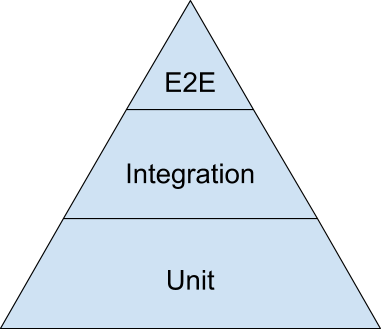

# Unit Testing
- Isolated (test one thing at a time)
- Small (it is an example of usage)
- Deterministic (always gives the same answer)

*   https://docs.python-guide.org/writing/tests/
*   https://realpython.com/python-testing/
*   https://www.freecodecamp.org/news/learning-to-test-with-python-997ace2d8abe/

In [ ]:
# do one thing at a time 
# develop something deterministic (rather than schotastic?)

## Practice: Test the function below using what we have learned so far

Create a Python script named `factorial.py`, and perform the following steps:
* Copy and paste the function factorial into this Python script.
* Add a main function, which requests an input from user, and calls factorial with user input `n`
* Call the main function

Create another Python script named `test_factorial.py`, and perform the following tasks:
* import factorial from factorial.py
* Craft a few test cases to verify the output of factorial function

In [ ]:
def factorial(n):
    if n < 0:
        return None
    if n == 0:
        return 1
    result = 1
    for i in range(1, n + 1):
        result *= i
    return result


### Manual tests

In [ ]:
print(factorial(0))  # Expected output: 1
print(factorial(1))  # Expected output: 1
print(factorial(5))  # Expected output: 120
print(factorial(10))  # Expected output: 3628800
# Test for negative input, it should raise a ValueError
print(factorial(-1))


## Assert Keyword

We can improve our code using a keyword `assert`.

The assert keyword in Python is used to test whether a condition is true. If the condition evaluates to True, the program continues executing. If the condition evaluates to False, an AssertionError is raised, and the program halts (unless the exception is caught).

In [1]:
x = 5
assert x > 0

y = -1
assert y > 0

AssertionError: 

While both `assert` and `if` statements check conditions, assert is specifically meant for debugging and testing

* Assert always raises an exception when the condition fails.

* An if statement provides more flexibility (e.g., you can handle the false condition without raising exceptions).

## Practice: Use Assert Keyword for Unit Test

Revise `test_factorial.py` using assertions to test the factorial function


## Practice: Use Error Handling to Generate More Readable Output

Revise `test_factorial.py` using error handling to make output more readable


## Unit Test using Pytest

Pytest is a third-party package for unit test.

To check if you have pytest installed, type `pytest --version` in terminal.

If you do not have pytest installed, you can install it using `pip install pytest`.

### Practice: 
Copy and paste the following code to your `test_factorial.py`

In your terminal, type `pytest test_factorial.py`. What do you see?

Introduce a bug to your `factorial.py` script. Re-type `pytest test_factorial.py` in your terminal. What do you see?

Do you understand the results?

In [ ]:
from factorial import factorial


def test_factorial():
    assert factorial(-1) == None
    assert factorial(0) == 1
    assert factorial(2) == 2
    assert factorial(3) == 6



**Note**: Our function name should start with `test_` to use pytest.

### Practice: Test by Category

The previous practice stops when the first assertion is false. Sometimes it might be helpful to go through all test cases.

This requires test by categories.

Categorize your test cases into multiple functions. Repeat the previous exercise, what do you see? Do you understand the output?

In [ ]:
# If I want to test my factorial function 


## Test for Exceptions

Copy and paste the following factorial function to your `factorial.py`

Note that now a ValueError is raised when n is negative

In [ ]:
def factorial(n):
    if n < 0:
        raise ValueError("Factorial is not defined for negative numbers.")
    if n == 0:
        return 1
    result = 1
    for i in range(1, n + 1):
        result *= i
    return result

To test exceptions, we can use the following code to replace test_factorial_negative:

In [ ]:
import pytest


def test_factorial_negative():
    with pytest.raises(ValueError):
        factorial(-1)

## Practice: Side Effects that Are Not Testable

Create a Python script named `greet.py`

Copy the following code to the Python script. 

Is this function testable? Can you write a program named `test_greet.py` using pytest?

In [2]:
def main():
    usr = input("Enter your user name: ")
    greet(usr)


def greet(usr="class"):
    print(f"Hello, {usr}")


if __name__ == "__main__":
    main()

Hello, veronika


## Optional: Organize your test functions into a folder

We can have all test functions into a folder or directory. Let's call this folder test.

Create a file named `__init__.py` in the folder.

Then we can use `pytest test` to run all tests in the folder

## Optional: Performance testing

In [ ]:
import timeit

# Define a function to measure the execution time
def measure_factorial_performance():
    n = 1000  # Adjust the value of n for your performance test
    executions = 40
    execution_time = timeit.timeit(lambda: factorial(n), number=executions)
    avg_execution_time = execution_time / executions
    return avg_execution_time

# Perform the performance test
avg_time = measure_factorial_performance()

print(f"Average execution time for factorial(10): {avg_time:.6f} seconds")

# What is PEP8 style guide:
* class names should be CamelCase (MyClass)
* variable names should be snake_case and all lowercase (first_name)
* function names should be snake_case and all lowercase (quick_sort())
* constants should be snake_case and all uppercase (PI = 3.14159)
* modules should have short, snake_case names and all lowercase (numpy)
* single quotes and double quotes are treated the same (just pick one and be consistent)

PEP 8 line formatting:
* indent using 4 spaces (spaces are preferred over tabs)
* lines should not be longer than 79 characters
* avoid multiple statements on the same line
* top-level function and class definitions are surrounded with two blank lines
* method definitions inside a class are surrounded by a single blank line
* imports should be on separate lines

PEP 8 whitespace:
* avoid extra spaces within brackets or braces
* avoid trailing whitespace anywhere
* always surround binary operators with a single space on either side
* if operators with different priorities are used, consider adding whitespace * around the operators with the lowest priority
* don't use spaces around the = sign when used to indicate a keyword argument

PEP 8 comments:
* comments should not contradict the code
* comments should be complete sentences
* comments should have a space after the # sign with the first word capitalized
* multi-line comments used in functions (docstrings) should have a short single-line description followed by more text